<a href="https://colab.research.google.com/github/kesavan6442/ENERGY/blob/main/energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
data = pd.read_csv("energydata_complete.csv", engine='python', on_bad_lines='skip')
data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:

data['date'] = pd.to_datetime(data['date'])

data['hour'] = data['date'].dt.hour
data['day'] = data['date'].dt.day
data['month'] = data['date'].dt.month
data['weekday'] = data['date'].dt.weekday

data = data[(data['Appliances'] > 10) & (data['Appliances'] < 250)]

In [5]:

data['prev_1'] = data['Appliances'].shift(1)
data['prev_2'] = data['Appliances'].shift(2)

data['rolling_mean'] = data['Appliances'].rolling(3).mean()

data['temp_humidity'] = data['T1'] * data['RH_1']
data['outdoor_effect'] = data['T_out'] * data['RH_out']

data = data.dropna()

In [6]:
features = [
    'T1','RH_1','T2','RH_2','T3','RH_3',
    'T_out','RH_out',
    'hour','day','month','weekday',
    'lights',
    'prev_1','prev_2','rolling_mean',
    'temp_humidity','outdoor_effect'
]

X = data[features]
y = data['Appliances']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [9]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300,
                          random_state=42)

In [12]:
gb_pred = gb_model.predict(X_test)

print(" Gradient Boosting Results")
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("R2 Score:", r2_score(y_test, gb_pred))

 Gradient Boosting Results
MAE: 1.6541919370719491
R2 Score: 0.9931922006838211


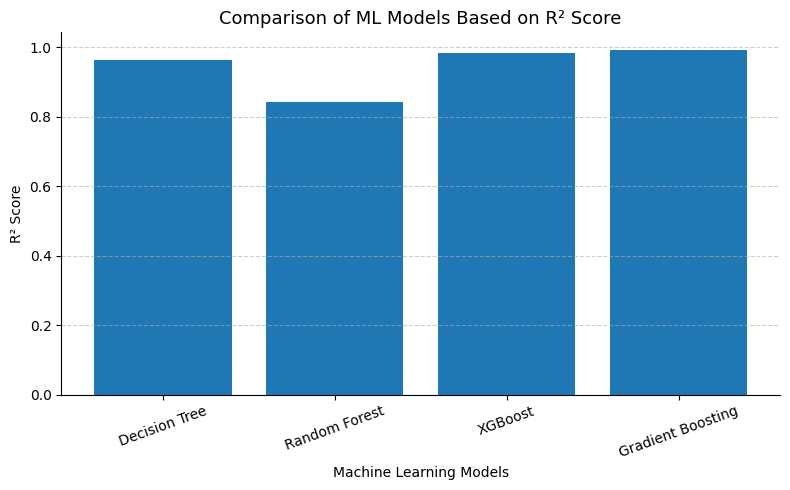

In [13]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest', 'XGBoost', 'Gradient Boosting']
r2_scores = [0.9620, 0.8417, 0.9819, 0.9931]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title('Comparison of ML Models Based on R² Score', fontsize=13)
plt.xlabel('Machine Learning Models')
plt.ylabel('R² Score')

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('model_comparison_r2.png', dpi=300)

plt.show()